<a href="https://colab.research.google.com/github/Saroj-lab/Assessment1/blob/main/Visualizations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import seaborn as sns

In [4]:
df = sns.load_dataset('tips')
sns.set_theme(style='whitegrid')

In [6]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [7]:
df.shape

(244, 7)

In [8]:
df.value_counts()

,,,,,,,count
total_bill,tip,sex,smoker,day,time,size,
13.00,2.00,Female,Yes,Thur,Lunch,2,2
5.75,1.00,Female,Yes,Fri,Dinner,2,1
3.07,1.00,Female,Yes,Sat,Dinner,1,1
7.25,5.15,Male,Yes,Sun,Dinner,2,1
7.51,2.00,Male,No,Thur,Lunch,2,1
...,...,...,...,...,...,...,...
45.35,3.50,Male,Yes,Sun,Dinner,3,1
48.17,5.00,Male,No,Sun,Dinner,6,1
48.27,6.73,Male,No,Sat,Dinner,4,1


In [9]:
df['day'].value_counts(normalize=True) * 100

,proportion
day,
Sat,35.655738
Sun,31.147541
Thur,25.409836
Fri,7.786885


AttributeError: 'DataFrame' object has no attribute 'value'

In [11]:
df['sex'].value_counts(normalize=True) * 100

,proportion
sex,
Male,64.344262
Female,35.655738


In [15]:
print("smoking ratio of genders")

gender_smoking_pct = pd.crosstab(df['sex'], df['smoker'], normalize='index') * 100

print(gender_smoking_pct)

smoking ratio of genders
smoker        Yes         No
sex                         
Male    38.216561  61.783439
Female  37.931034  62.068966


In [14]:

df['bill_to_tip_ratio'] = df['total_bill'] / df['tip']


with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(df)

,total_bill,tip,sex,smoker,day,time,size,tip_ratio,tip_percentage,bill_to_tip_ratio
0,16.99,1.01,Female,No,Sun,Dinner,2,0.059447,5.944673,16.821782
1,10.34,1.66,Male,No,Sun,Dinner,3,0.160542,16.054159,6.228916
2,21.01,3.50,Male,No,Sun,Dinner,3,0.166587,16.658734,6.002857
3,23.68,3.31,Male,No,Sun,Dinner,2,0.139780,13.978041,7.154079
4,24.59,3.61,Female,No,Sun,Dinner,4,0.146808,14.680765,6.811634
5,25.29,4.71,Male,No,Sun,Dinner,4,0.186240,18.623962,5.369427
6,8.77,2.00,Male,No,Sun,Dinner,2,0.228050,22.805017,4.385000
7,26.88,3.12,Male,No,Sun,Dinner,4,0.116071,11.607143,8.615385
8,15.04,1.96,Male,No,Sun,Dinner,2,0.130319,13.031915,7.673469
9,14.78,3.23,Male,No,Sun,Dinner,2,0.218539,21.853857,4.575851


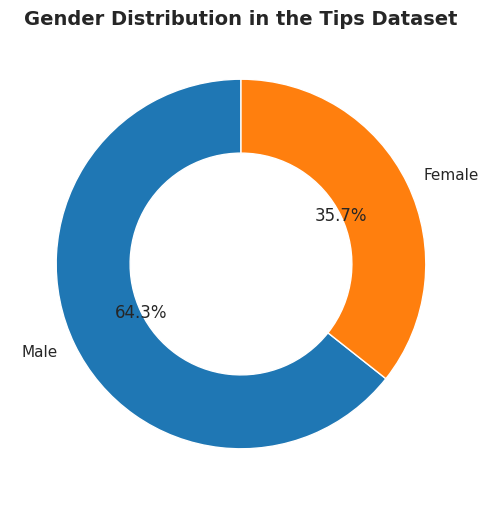

In [17]:
gender_counts = df['sex'].value_counts()

# 2. Plot the pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#1f77b4', '#ff7f0e'], # Blue for Male, Orange for Female
    wedgeprops=dict(width=0.4, edgecolor='w') # Makes it a clean donut chart
)

plt.title("Gender Distribution in the Tips Dataset", weight='bold', fontsize=14)
plt.show()

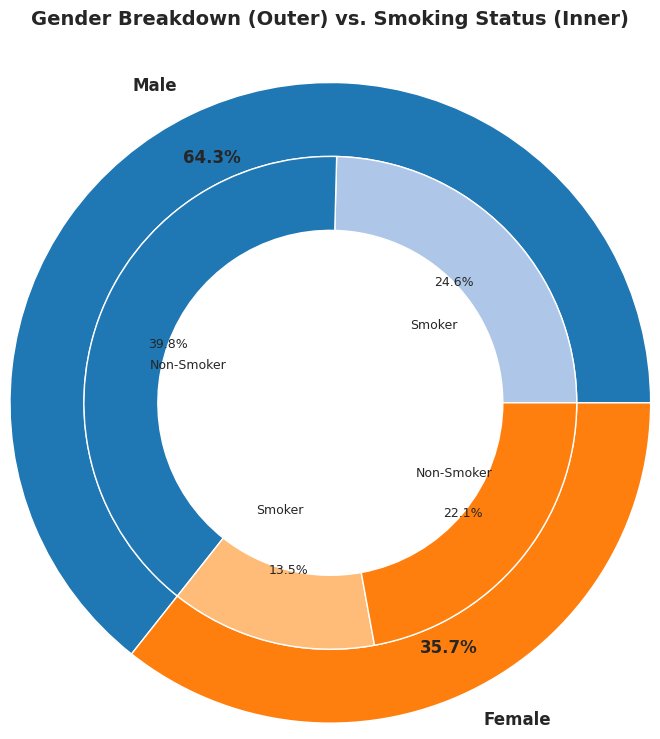

In [18]:
gender_counts = df['sex'].value_counts()
gender_labels = gender_counts.index

inner_counts = df.groupby(['sex', 'smoker'], observed=False).size()

inner_sizes = [
    inner_counts[('Male', 'Yes')], inner_counts[('Male', 'No')],
    inner_counts[('Female', 'Yes')], inner_counts[('Female', 'No')]
]
inner_labels = ['Smoker', 'Non-Smoker', 'Smoker', 'Non-Smoker']

colors_outer = ['#1f77b4', '#ff7f0e']
colors_inner = ['#aec7e8', '#1f77b4', '#ffbb78', '#ff7f0e']

fig, ax = plt.subplots(figsize=(8, 8))

ax.pie(
    gender_counts,
    labels=gender_labels,
    radius=1.3,
    colors=colors_outer,
    autopct='%1.1f%%',
    pctdistance=0.85,
    wedgeprops=dict(width=0.3, edgecolor='w'),
    textprops={'fontsize': 12, 'weight': 'bold'}
)

ax.pie(
    inner_sizes,
    labels=inner_labels,
    radius=1.0,
    colors=colors_inner,
    autopct='%1.1f%%',
    pctdistance=0.70,
    labeldistance=0.45,
    wedgeprops=dict(width=0.3, edgecolor='w'),
    textprops={'fontsize': 9}
)

plt.title("Gender Breakdown (Outer) vs. Smoking Status (Inner)", y=1.1, fontsize=14, weight='bold')
plt.show()

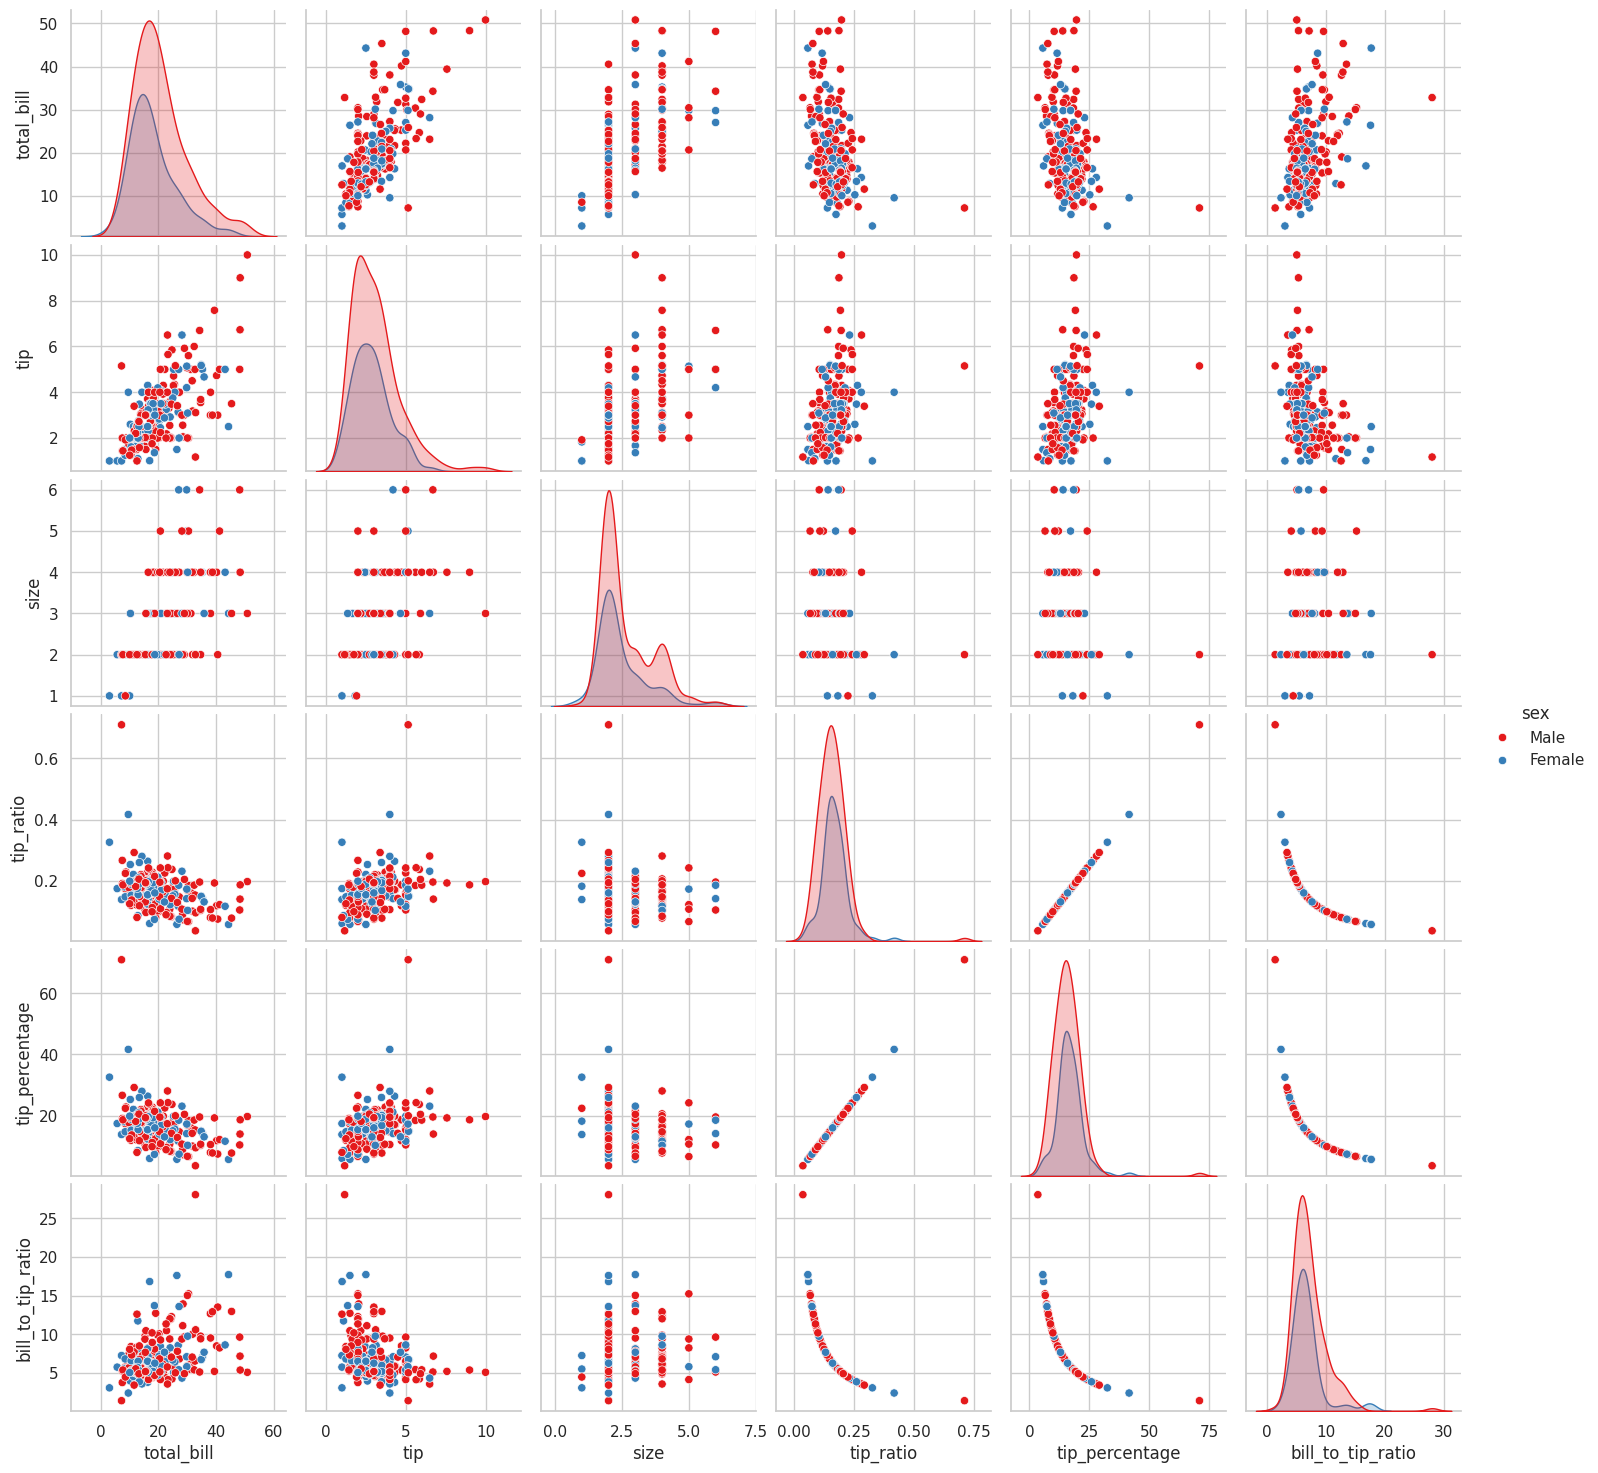

In [19]:
sns.pairplot(data=df, hue="sex", palette="Set1")
plt.show()

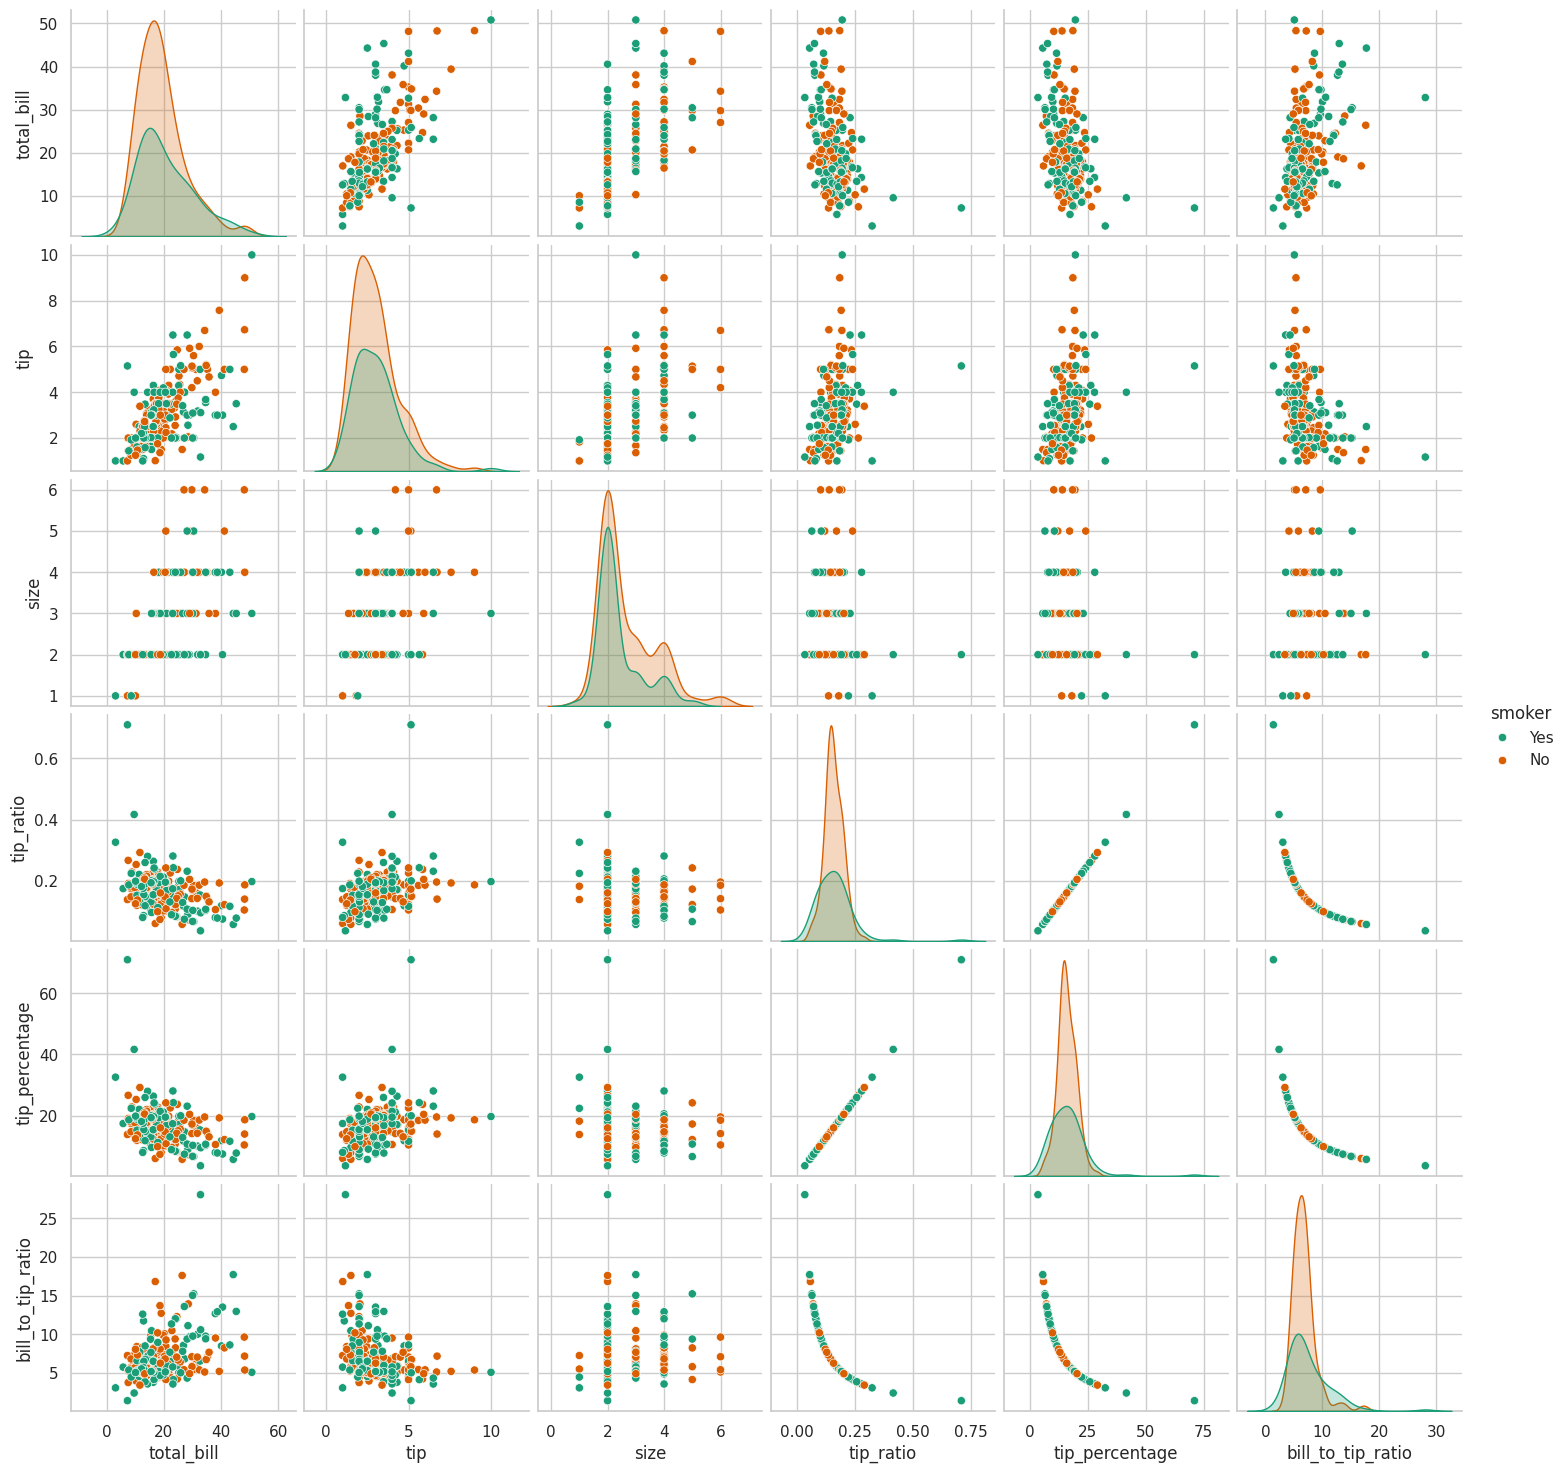

In [20]:
sns.pairplot(data=df, hue="smoker", palette="Dark2")
plt.show()

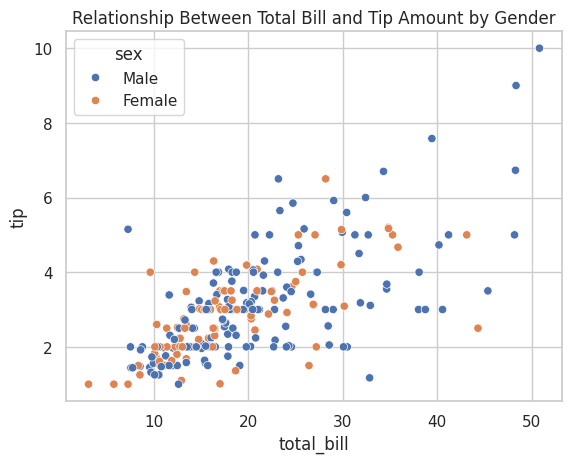

In [21]:
sns.scatterplot(
    data=df,
    x="total_bill",
    y="tip",
    hue="sex"
)

plt.title("Relationship Between Total Bill and Tip Amount by Gender")
plt.show()

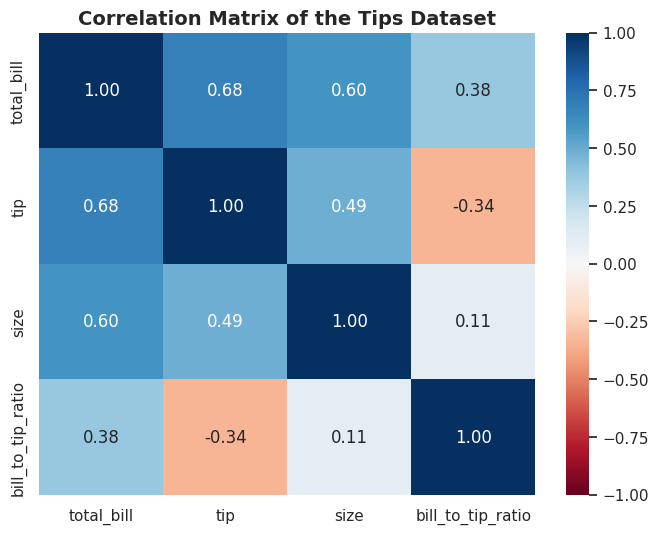

In [22]:
numerical_df = df[['total_bill', 'tip', 'size', 'bill_to_tip_ratio']]
corr_matrix = numerical_df.corr()


plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="RdBu", vmin=-1, vmax=1, fmt=".2f")

plt.title("Correlation Matrix of the Tips Dataset", weight='bold', fontsize=14)
plt.show()

<Axes: xlabel='sex', ylabel='total_bill'>

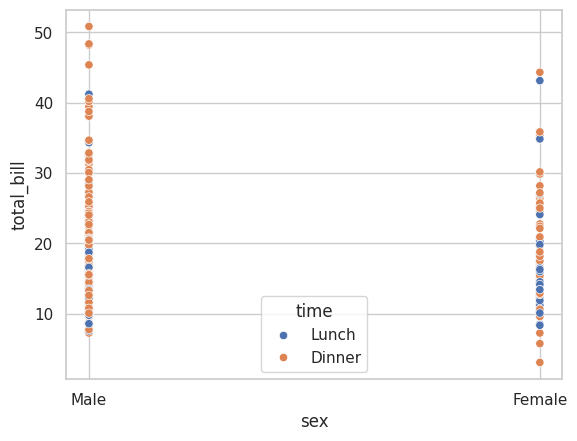

In [25]:
sns.scatterplot(data=df,x="sex",y="total_bill",hue="time")

<Axes: xlabel='sex', ylabel='total_bill'>

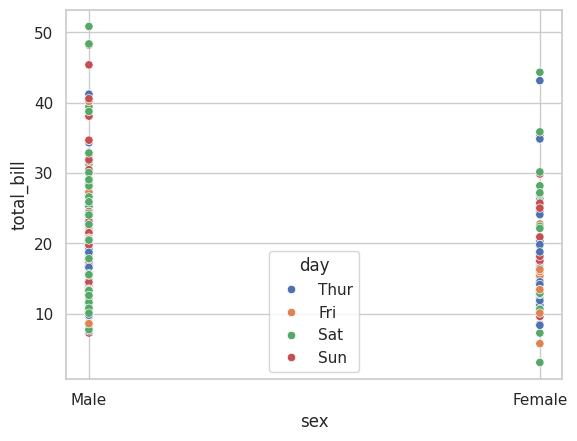

In [26]:
sns.scatterplot(data=df,x="sex",y="total_bill",hue="day")

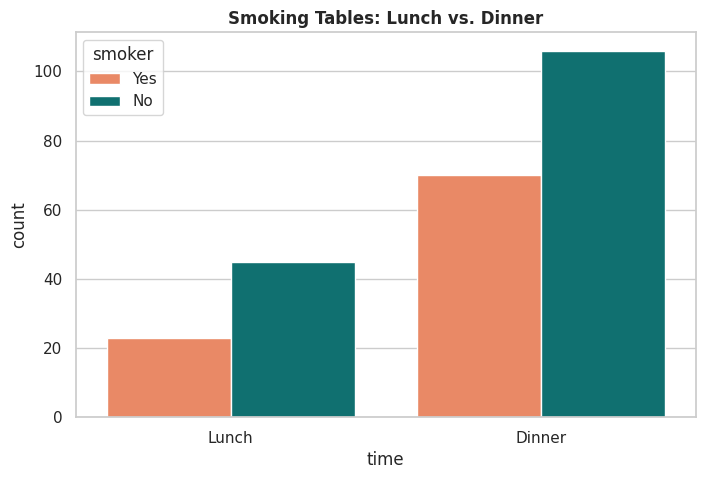

In [27]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='time', hue='smoker', palette={"No": "#008080", "Yes": "#FF7F50"}, order=['Lunch', 'Dinner'])
plt.title('Smoking Tables: Lunch vs. Dinner', weight='bold')
plt.show()

/tmp/ipykernel_3077/3209879972.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='time', y='total_bill', palette='Set2')


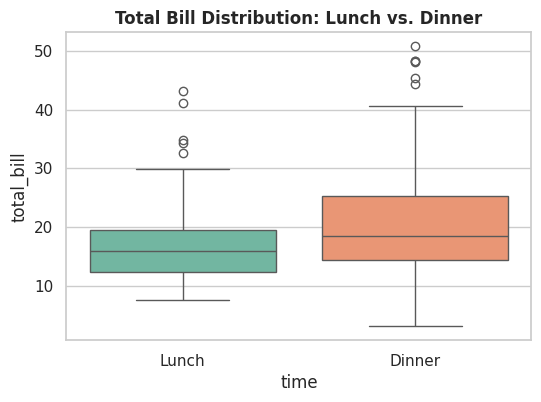

In [28]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='time', y='total_bill', palette='Set2')
plt.title('Total Bill Distribution: Lunch vs. Dinner', weight='bold')
plt.show()

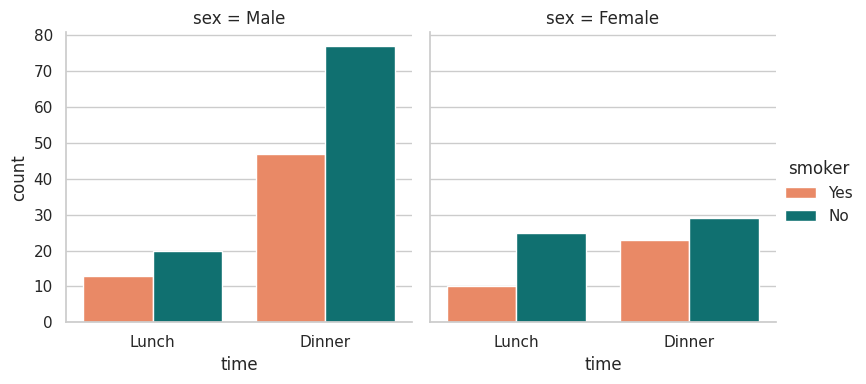

In [29]:
sns.catplot(
    data=df,
    x="time",
    hue="smoker",
    col="sex",
    kind="count",
    palette={"No": "#008080", "Yes": "#FF7F50"},
    height=4,
    aspect=1
)
plt.show()

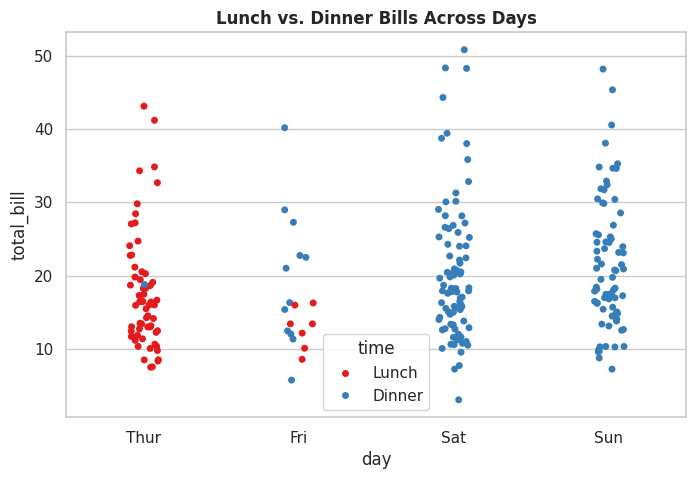

In [30]:
plt.figure(figsize=(8, 5))
sns.stripplot(
    data=df,
    x="day",
    y="total_bill",
    hue="time",
    jitter=True,
    palette="Set1",
    order=["Thur", "Fri", "Sat", "Sun"]
)
plt.title("Lunch vs. Dinner Bills Across Days", weight="bold")
plt.show()

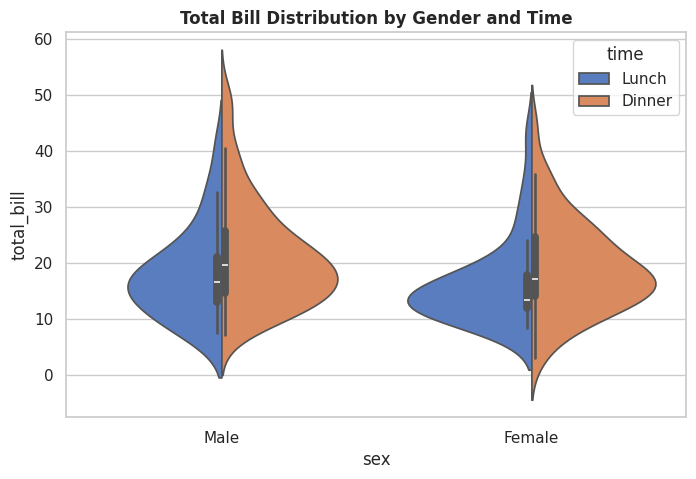

In [31]:
plt.figure(figsize=(8, 5))
sns.violinplot(
    data=df,
    x="sex",
    y="total_bill",
    hue="time",
    split=True,
    palette="muted"
)
plt.title("Total Bill Distribution by Gender and Time", weight="bold")
plt.show()